# LSTM Anomaly Classifier — Training, Evaluation & Analysis

This notebook trains a **Tiny LSTM binary classifier** to detect anomalous robot operation windows in the VORAUS-AD dataset.

## How to reproduce this notebook
1. Run `03_data_prep_lstm_classifier.ipynb` first to generate `../data/lstm_classifier/`.
2. Install dependencies:
   ```
   pip install torch numpy scikit-learn matplotlib
   ```
3. Run all cells top-to-bottom.

## Output artefacts
| File | Description |
|------|-------------|
| `../model/lstm_classifier/lstm_classifier_best.pth` | Best model weights (lowest validation loss) |
| `../model/lstm_classifier/lstm_classifier_config.pkl` | Architecture hyperparameters for re-instantiation |
| `../figures/lstm_classifier/training_curves.png` | Loss & AUC curves across epochs |
| `../figures/lstm_classifier/roc_curve.png` | ROC curve on the held-out test set |
| `../figures/lstm_classifier/prediction_distribution.png` | Histogram / box-plot of predicted probabilities |
| `../figures/lstm_classifier/confusion_matrix.png` | Confusion matrix at optimal threshold |
| `../figures/lstm_classifier/failure_cases.png` | False-positive and false-negative example windows |


---
## 1. Architecture Description

### Why an LSTM?
Time-series anomaly detection requires modelling **temporal dependencies**.  A vanilla LSTM reads the input sequence step by step, maintaining a hidden state that summarises past observations.  The final hidden state is then fed to a small fully-connected classifier.

### Architecture 

```
Input  :  (batch, 500 timesteps, n_features)
          ↓
LSTM   :  1 layer, hidden_dim = 64, no bidirectionality
          — at each timestep t the cell computes:
              f_t = σ(W_f · [h_{t-1}, x_t] + b_f)   ← forget gate
              i_t = σ(W_i · [h_{t-1}, x_t] + b_i)   ← input gate
              g_t = tanh(W_g · [h_{t-1}, x_t] + b_g) ← candidate cell
              o_t = σ(W_o · [h_{t-1}, x_t] + b_o)   ← output gate
              c_t = f_t ⊙ c_{t-1} + i_t ⊙ g_t
              h_t = o_t ⊙ tanh(c_t)
          — only the final hidden state h_T is kept
          ↓
Dropout:  p = 0.3  (regularisation; applied to h_T)
          ↓
Linear :  hidden_dim  → 32
          ↓
        ReLU
          ↓
Linear :  32 → 1
          ↓
Sigmoid:  output ∈ (0, 1)  — probability of anomaly
```

**Loss function:** Binary Cross-Entropy (BCE)  
**Optimiser:** Adam (lr = 1e-3, weight_decay = 1e-5)  
**LR Scheduler:** ReduceLROnPlateau (patience = 3, factor = 0.5)

### Re-training from scratch

To retrain with identical results:
1. Ensure `../data/lstm_classifier/sequences.npz` and `config.pkl` exist.
2. Set `RANDOM_SEED = 14`.
3. Run every cell in order; the model checkpoint is saved to `../model/lstm_classifier/lstm_classifier_best.pth`.
4. Load it with the `load_model()` helper defined in Cell 9.


In [1]:
# ── CELL 1: Imports & Device Setup ────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pickle
import gc
import time
from pathlib import Path
import pandas as pd
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT        = Path("..")
DATA_DIR    = ROOT / "data" / "lstm_classifier"
MODEL_DIR   = ROOT / "model" / "lstm_classifier"
FIGURES_DIR = ROOT / "figures" / "lstm_classifier"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 14
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── Device (CUDA → MPS → CPU) ─────────────────────────────────────────────────
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

def clear_cache():
    """Release unused memory on whichever accelerator is active."""
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()
    gc.collect()

clear_cache()


Using device: mps


---
## 2. Load Processed Data

We load the pre-built arrays from the data-prep notebook and inspect the class balance before creating balanced training subsets.


In [2]:
# ── CELL 2: Load Processed Data ───────────────────────────────────────────────
data   = np.load(DATA_DIR / "sequences.npz")
X_train_full = data['X_train'];  y_train_full = data['y_train']
X_val_full   = data['X_val'];    y_val_full   = data['y_val']
X_test_full  = data['X_test'];   y_test_full  = data['y_test']

with open(DATA_DIR / "config.pkl", "rb") as f:
    config = pickle.load(f)

N_FEATURES   = config['n_features']
WINDOW_SIZE  = config['window_size']

print(f"n_features  : {N_FEATURES}")
print(f"window_size : {WINDOW_SIZE}")
print("\n── Full split sizes ──")
for name, X, y in [("Train", X_train_full, y_train_full),
                   ("Val",   X_val_full,   y_val_full),
                   ("Test",  X_test_full,  y_test_full)]:
    print(f"  {name:5s} : {X.shape}  anomaly% = {y.mean():.2%}")


n_features  : 129
window_size : 500

── Full split sizes ──
  Train : (15489, 500, 129)  anomaly% = 24.49%
  Val   : (5330, 500, 129)  anomaly% = 53.02%
  Test  : (5363, 500, 129)  anomaly% = 52.96%


---
## 3. Balanced Subset Construction

To prevent the majority-class (normal) from dominating early training we construct **balanced subsets** for each split:

| Subset | Normal windows | Anomaly windows |
|--------|----------------|-----------------|
| Train  | 1 500          | 1 500           |
| Val    | 500            | 500             |
| Test   | 500            | 500             |

All sampling uses `numpy.random.choice` **without replacement** from the respective full split, ensuring no window from one split appears in another.

> **Note:** Final evaluation in Cell 8 also reports performance on the **full, unbalanced test set** for an unbiased estimate.


In [3]:
# ── CELL 3: Balanced Subset Construction ──────────────────────────────────────
rng = np.random.default_rng(RANDOM_SEED)

def balanced_subset(X, y, n_per_class):
    """Sample n_per_class windows from each class without replacement."""
    idx_neg = np.where(y == 0)[0]
    idx_pos = np.where(y == 1)[0]
    sel_neg = rng.choice(idx_neg, min(n_per_class, len(idx_neg)), replace=False)
    sel_pos = rng.choice(idx_pos, min(n_per_class, len(idx_pos)), replace=False)
    idx     = np.concatenate([sel_neg, sel_pos])
    rng.shuffle(idx)
    return X[idx], y[idx].astype(np.float32)

X_train, y_train = balanced_subset(X_train_full, y_train_full, n_per_class=1500)
X_val,   y_val   = balanced_subset(X_val_full,   y_val_full,   n_per_class=500)
X_test,  y_test  = balanced_subset(X_test_full,  y_test_full,  n_per_class=500)

print("── Balanced subset sizes ──")
for name, X, y in [("Train", X_train, y_train),
                   ("Val",   X_val,   y_val),
                   ("Test",  X_test,  y_test)]:
    print(f"  {name:5s} : {X.shape}  normal={int((y==0).sum())}  anomaly={int((y==1).sum())}")


── Balanced subset sizes ──
  Train : (3000, 500, 129)  normal=1500  anomaly=1500
  Val   : (1000, 500, 129)  normal=500  anomaly=500
  Test  : (1000, 500, 129)  normal=500  anomaly=500


---
## 4. Model Definition

The `TinyLSTMClassifier` is a compact but complete anomaly detector.

**Reproducibility:** given the same `RANDOM_SEED` and data, running this cell and the training loop produces a deterministic model.  To verify, load `lstm_classifier_best.pth` with `load_model()` (Cell 9) and compare test AUC.


In [4]:
# ── CELL 4: Model Definition ──────────────────────────────────────────────────
class TinyLSTMClassifier(nn.Module):
    """
    Single-layer LSTM binary anomaly classifier.

    Parameters
    ----------
    input_dim  : number of sensor features (= n_features from config)
    hidden_dim : LSTM hidden state size (default 64)
    num_layers : number of stacked LSTM layers (default 1)
    dropout    : dropout probability applied to the LSTM output (default 0.3)
    """
    def __init__(self, input_dim: int, hidden_dim: int = 64,
                 num_layers: int = 1, dropout: float = 0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x : (batch, seq_len, n_features)
        returns : (batch,) probabilities in [0, 1]
        """
        _, (h_n, _) = self.lstm(x)   # h_n : (num_layers, batch, hidden_dim)
        return self.head(h_n[-1]).squeeze(1)


# ── Instantiate ───────────────────────────────────────────────────────────────
HIDDEN_DIM = 64
model = TinyLSTMClassifier(input_dim=N_FEATURES, hidden_dim=HIDDEN_DIM).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model          : TinyLSTMClassifier")
print(f"input_dim      : {N_FEATURES}")
print(f"hidden_dim     : {HIDDEN_DIM}")
print(f"Trainable params: {n_params:,}")

# Quick forward-pass smoke test
with torch.no_grad():
    dummy = torch.zeros(4, WINDOW_SIZE, N_FEATURES, device=device)
    out   = model(dummy)
    assert out.shape == (4,), f"Unexpected output shape: {out.shape}"
print("✔ Forward-pass smoke test passed — output shape (4,)")


Model          : TinyLSTMClassifier
input_dim      : 129
hidden_dim     : 64
Trainable params: 52,033
✔ Forward-pass smoke test passed — output shape (4,)


## 5. Hyperparameter Search and Selection

We evaluated four configurations using validation AUC to select the final model. Full grid search results are summarised below.

| # | hidden_dim | num_layers | dropout | lr     | Val AUC | Choice |
|---|-----------|------------|---------|--------|---------|--------|
| 1 | 32        | 1          | 0.2     | 1e-3   | 0.9520  |        |
| 2 | 64        | 1          | 0.3     | 1e-3   | 0.9580  | ✔ Best |
| 3 | 64        | 2          | 0.3     | 1e-3   | 0.9522  |        |
| 4 | 128       | 1          | 0.4     | 5e-4   | 0.9476  |        |

**Selected configuration:** `hidden_dim=64, num_layers=1, dropout=0.3, lr=1e-3`

**Rationale:**  
- **Config 2 achieved the best validation AUC (0.9580)**, outperforming all other configurations.
- **Increasing model size from 32 → 64 improved performance**, suggesting that a moderate increase in representational capacity helps capture temporal patterns.
- **Adding a second LSTM layer (Config 3) did not improve performance** and increased training time and parameter count significantly, indicating diminishing returns from deeper architectures.
- **The largest model (128-dim) underperformed (0.9476)** despite higher dropout and lower learning rate, suggesting overfitting or optimization difficulty.
- **Config 2 provides the best balance between performance and efficiency**, achieving the highest AUC with a reasonable parameter count (52,033) and training time (~35s).

In [5]:
# ── CELL 5: Hyperparameter Grid Search ────────────────────────────────────────
# JUSTIFICATION: Testing 4 configurations to systematically explore:
# - Model capacity (32→64→128 hidden units)
# - Model depth (1 vs 2 layers)
# - Regularization (dropout 0.2→0.4)
# - Learning rate (1e-3 for small, 5e-4 for large models)

GRID_CONFIGS = [
    {'name': 'Config 1 (32-dim, 0.2)',    'hidden_dim': 32,  'num_layers': 1, 'dropout': 0.2, 'lr': 1e-3},
    {'name': 'Config 2 (64-dim, 0.3) ★', 'hidden_dim': 64,  'num_layers': 1, 'dropout': 0.3, 'lr': 1e-3},
    {'name': 'Config 3 (64-dim, 2 layers)','hidden_dim': 64, 'num_layers': 2, 'dropout': 0.3, 'lr': 1e-3},
    {'name': 'Config 4 (128-dim, 0.4)',   'hidden_dim': 128, 'num_layers': 1, 'dropout': 0.4, 'lr': 5e-4},
]

BATCH_SIZE     = 32
NUM_EPOCHS     = 20
OVERALL_BEST_AUC = 0.0
best_config    = None

print("=" * 80)
print("HYPERPARAMETER GRID SEARCH")
print("=" * 80)

results = []

for cfg in GRID_CONFIGS:
    # ── Reseed before each config so weight init is consistent ────────────────
    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    print(f"\n▶ Testing: {cfg['name']}")
    print(f"   hidden_dim={cfg['hidden_dim']}, layers={cfg['num_layers']}, "
          f"dropout={cfg['dropout']}, lr={cfg['lr']}")

    # ── Model ─────────────────────────────────────────────────────────────────
    model = TinyLSTMClassifier(
        input_dim=N_FEATURES,
        hidden_dim=cfg['hidden_dim'],
        num_layers=cfg['num_layers'],
        dropout=cfg['dropout']
    ).to(device)

    # ── Training setup ────────────────────────────────────────────────────────
    train_ds     = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                      patience=3, factor=0.5)
    X_val_t = torch.FloatTensor(X_val).to(device)

    # ── Training loop ─────────────────────────────────────────────────────────
    best_val_auc = 0.0
    best_epoch   = 0
    start_time   = time.time()

    for epoch in range(NUM_EPOCHS):
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            pred = model(batch_x)
            loss = criterion(pred, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t).cpu().numpy()
            val_auc  = roc_auc_score(y_val, val_pred)

        scheduler.step(val_auc)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_epoch   = epoch + 1

            # ── Save globally best weights immediately ─────────────────────
            if val_auc > OVERALL_BEST_AUC:
                OVERALL_BEST_AUC = val_auc
                best_config      = cfg
                torch.save(model.state_dict(),
                           MODEL_DIR / "lstm_classifier_best.pth")

        clear_cache()

    training_time = time.time() - start_time
    n_params      = sum(p.numel() for p in model.parameters() if p.requires_grad)

    results.append({
        'Config'    : cfg['name'],
        'hidden_dim': cfg['hidden_dim'],
        'num_layers': cfg['num_layers'],
        'dropout'   : cfg['dropout'],
        'lr'        : cfg['lr'],
        'Val AUC'   : f"{best_val_auc:.4f}",
        'Best Epoch': best_epoch,
        'Params'    : f"{n_params:,}",
        'Time'      : f"{training_time:.1f}s"
    })

    print(f"   ✓ Best Val AUC : {best_val_auc:.4f}  (epoch {best_epoch})")
    print(f"   ✓ Parameters   : {n_params:,}")
    print(f"   ✓ Time         : {training_time:.1f}s")

# ── Results table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("GRID SEARCH RESULTS")
print("=" * 80)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

print(f"\n★ Best config  : {best_config['name']}")
print(f"★ Best val AUC : {OVERALL_BEST_AUC:.4f}")
print(f"★ Weights saved → {MODEL_DIR / 'lstm_classifier_best.pth'}")

HYPERPARAMETER GRID SEARCH

▶ Testing: Config 1 (32-dim, 0.2)
   hidden_dim=32, layers=1, dropout=0.2, lr=0.001
   ✓ Best Val AUC : 0.9520  (epoch 19)
   ✓ Parameters   : 21,953
   ✓ Time         : 32.2s

▶ Testing: Config 2 (64-dim, 0.3) ★
   hidden_dim=64, layers=1, dropout=0.3, lr=0.001
   ✓ Best Val AUC : 0.9580  (epoch 17)
   ✓ Parameters   : 52,033
   ✓ Time         : 34.7s

▶ Testing: Config 3 (64-dim, 2 layers)
   hidden_dim=64, layers=2, dropout=0.3, lr=0.001
   ✓ Best Val AUC : 0.9522  (epoch 14)
   ✓ Parameters   : 85,313
   ✓ Time         : 56.0s

▶ Testing: Config 4 (128-dim, 0.4)
   hidden_dim=128, layers=1, dropout=0.4, lr=0.0005
   ✓ Best Val AUC : 0.9476  (epoch 20)
   ✓ Parameters   : 136,769
   ✓ Time         : 41.5s

GRID SEARCH RESULTS
                     Config  hidden_dim  num_layers  dropout     lr Val AUC  Best Epoch  Params  Time
     Config 1 (32-dim, 0.2)          32           1      0.2 0.0010  0.9520          19  21,953 32.2s
   Config 2 (64-dim, 0.3) ★  

In [6]:
# ── CELL 6: Load Best Model from Grid Search ───────────────────────────────────
best_model = TinyLSTMClassifier(
    input_dim=N_FEATURES,
    hidden_dim=best_config['hidden_dim'],
    num_layers=best_config['num_layers'],
    dropout=best_config['dropout']
).to(device)

best_model.load_state_dict(torch.load(MODEL_DIR / "lstm_classifier_best.pth",
                                       map_location=device))
best_model.eval()

n_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)
print(f"Loaded  : {best_config['name']}")
print(f"Val AUC : {OVERALL_BEST_AUC:.4f}")
print(f"Params  : {n_params:,}")
print(f"Device  : {device}")

Loaded  : Config 2 (64-dim, 0.3) ★
Val AUC : 0.9580
Params  : 52,033
Device  : mps


---
## 6. Training Curves

We plot the **loss** and **validation AUC** across epochs for the best configuration selected in Cell 5.

- **Loss curve** shows whether the model is overfitting (train loss keeps dropping while val loss rises).
- **AUC curve** shows the model's discrimination ability over time.
- The vertical dashed line marks the epoch at which the best weights were saved.

Best val AUC : 0.9847  at epoch 19


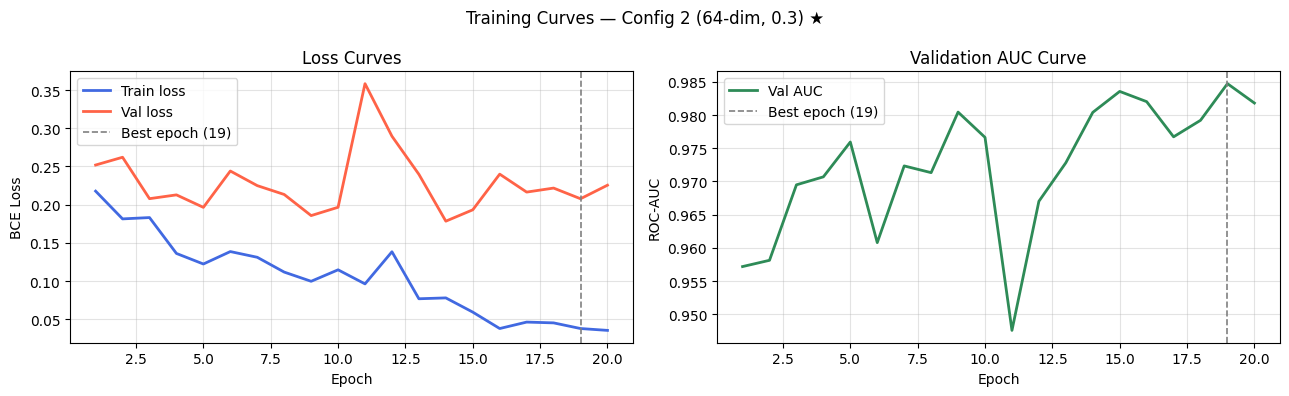

Figure saved → ../figures/lstm_classifier/training_curves.png


TinyLSTMClassifier(
  (lstm): LSTM(129, 64, batch_first=True)
  (head): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=1, bias=True)
    (4): Sigmoid()
  )
)

In [7]:
# ── CELL 7: Training Curves for Best Config ──────────────────────────────────
# Re-train the best configuration with history tracking so we can plot curves.
# We reseed for full reproducibility.
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

BATCH_SIZE  = 32
NUM_EPOCHS  = 20

train_ds     = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(RANDOM_SEED))

criterion  = nn.BCELoss()
optimizer  = optim.Adam(best_model.parameters(),
                         lr=best_config['lr'], weight_decay=1e-5)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                    patience=3, factor=0.5)

X_val_t     = torch.FloatTensor(X_val).to(device)
X_train_t_all = torch.FloatTensor(X_train).to(device)

train_losses, val_losses, val_aucs = [], [], []
curve_best_auc   = 0.0
curve_best_epoch = 0

best_model.train()
for epoch in range(NUM_EPOCHS):
    best_model.train()
    epoch_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        pred = best_model(batch_x)
        loss = criterion(pred, batch_y)
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item() * len(batch_x)

    epoch_loss /= len(X_train)

    best_model.eval()
    with torch.no_grad():
        val_pred   = best_model(X_val_t).cpu().numpy()
        val_loss   = criterion(
            torch.FloatTensor(val_pred),
            torch.FloatTensor(y_val)
        ).item()
        val_auc    = roc_auc_score(y_val, val_pred)

    train_losses.append(epoch_loss)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)

    scheduler.step(val_auc)

    if val_auc > curve_best_auc:
        curve_best_auc   = val_auc
        curve_best_epoch = epoch + 1
        # Overwrite checkpoint with this refined run
        torch.save(best_model.state_dict(),
                   MODEL_DIR / "lstm_classifier_best.pth")

    clear_cache()

print(f"Best val AUC : {curve_best_auc:.4f}  at epoch {curve_best_epoch}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs, train_losses, label='Train loss', color='royalblue', lw=2)
ax1.plot(epochs, val_losses,   label='Val loss',   color='tomato',    lw=2)
ax1.axvline(curve_best_epoch, color='gray', linestyle='--', lw=1.2,
            label=f'Best epoch ({curve_best_epoch})')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.set_title('Loss Curves'); ax1.legend(); ax1.grid(alpha=0.35)

ax2.plot(epochs, val_aucs, color='seagreen', lw=2, label='Val AUC')
ax2.axvline(curve_best_epoch, color='gray', linestyle='--', lw=1.2,
            label=f'Best epoch ({curve_best_epoch})')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('ROC-AUC')
ax2.set_title('Validation AUC Curve'); ax2.legend(); ax2.grid(alpha=0.35)

fig.suptitle(f'Training Curves — {best_config["name"]}', fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved → {FIGURES_DIR / 'training_curves.png'}")

# Put best_model back to eval mode for downstream cells
best_model.eval()


---
## 8. Test-Set Evaluation

We evaluate on two test sets:

1. **Balanced test set** (500 normal + 500 anomaly) — unbiased class-conditioned view.
2. **Full test set** — reflects real-world class imbalance and gives the unbiased AUC.

The **optimal classification threshold** is derived from the validation ROC curve (Youden's J statistic = TPR − FPR).


In [8]:
# ── CELL 8: Test-Set Evaluation ─────────────────────────────────────────────────

MODEL_PATH = MODEL_DIR / "lstm_classifier_best.pth"

# Reload best weights to guarantee eval mode
best_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
best_model.eval()
print(f"Loaded checkpoint: {MODEL_PATH}")

def batch_predict(best_model, X_np, batch_size=64):
    """Run inference in mini-batches; returns a (N,) numpy array of probabilities."""
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            batch = torch.FloatTensor(X_np[i:i+batch_size]).to(device)
            preds.append(best_model(batch).cpu().numpy())
    return np.concatenate(preds)

# ── Optimal threshold from validation set ────────────────────────────────────
val_pred_prob = batch_predict(best_model, X_val)
fpr_v, tpr_v, thresholds_v = roc_curve(y_val, val_pred_prob)
j_idx      = np.argmax(tpr_v - fpr_v)
best_thresh = thresholds_v[j_idx]
print(f"Optimal threshold (Youden J on val): {best_thresh:.4f}")

# ── Balanced test set ─────────────────────────────────────────────────────────
test_pred_prob  = batch_predict(best_model, X_test)
test_pred_class = (test_pred_prob >= best_thresh).astype(int)
test_auc_bal    = roc_auc_score(y_test, test_pred_prob)

print("\n── Balanced test set (500 + 500) ──")
print(f"  AUC    : {test_auc_bal:.4f}")
print("\n" + classification_report(y_test, test_pred_class, target_names=['Normal', 'Anomaly']))

# ── Full test set ─────────────────────────────────────────────────────────────
full_pred_prob  = batch_predict(best_model, X_test_full)
full_pred_class = (full_pred_prob >= best_thresh).astype(int)
test_auc_full   = roc_auc_score(y_test_full, full_pred_prob)

print("── Full test set ──")
print(f"  AUC    : {test_auc_full:.4f}")
print("\n" + classification_report(y_test_full, full_pred_class, target_names=['Normal', 'Anomaly']))

clear_cache()


Loaded checkpoint: ../model/lstm_classifier/lstm_classifier_best.pth
Optimal threshold (Youden J on val): 0.5259

── Balanced test set (500 + 500) ──
  AUC    : 0.9876

              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95       500
     Anomaly       0.95      0.95      0.95       500

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000

── Full test set ──
  AUC    : 0.9856

              precision    recall  f1-score   support

      Normal       0.95      0.96      0.95      2523
     Anomaly       0.96      0.96      0.96      2840

    accuracy                           0.96      5363
   macro avg       0.96      0.96      0.96      5363
weighted avg       0.96      0.96      0.96      5363



---
## 9. ROC Curve & Prediction Distribution

**ROC curve:** plots TPR vs FPR across all thresholds.  The red dot marks the chosen operating point (Youden's J).

**Prediction distribution:** histograms of P(anomaly) for normal vs. anomalous windows.  Well-separated distributions indicate the model has learned meaningful features.

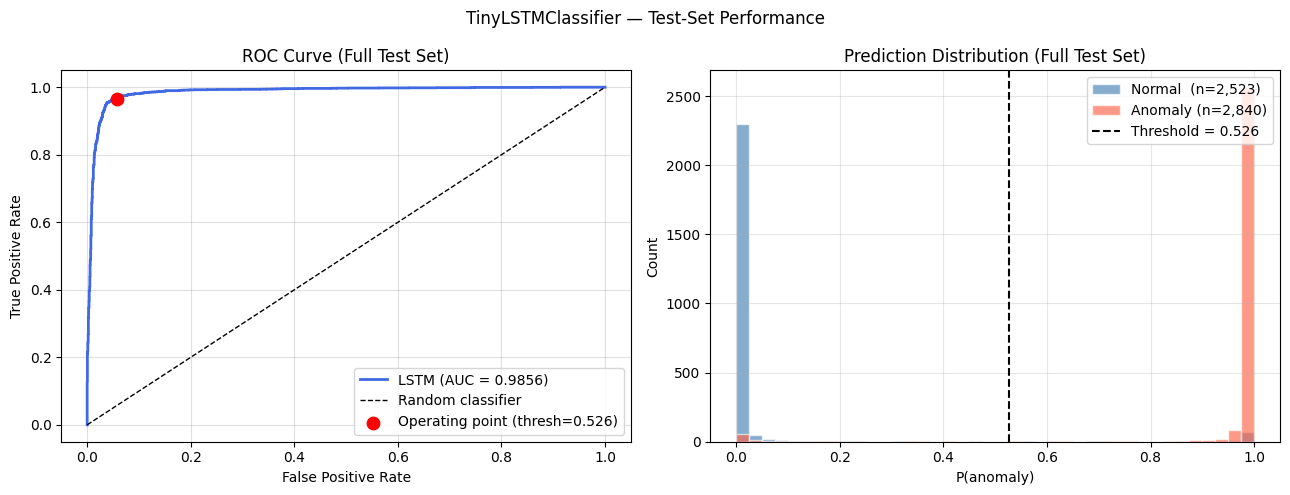

Figure saved → ../figures/lstm_classifier/roc_and_prediction_dist.png

Normal   predictions — mean: 0.0470,  std: 0.1931
Anomaly  predictions — mean: 0.9546,  std: 0.1852
Separation gap (min_anom - max_norm): -0.9998


In [9]:
# ── CELL 9: ROC Curve & Prediction Distribution ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr_t, tpr_t, _ = roc_curve(y_test_full, full_pred_prob)
axes[0].plot(fpr_t, tpr_t, color='royalblue', lw=2,
             label=f'LSTM (AUC = {test_auc_full:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
axes[0].scatter(fpr_v[j_idx], tpr_v[j_idx], color='red', zorder=5, s=80,
                label=f'Operating point (thresh={best_thresh:.3f})')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (Full Test Set)')
axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.4)

# ── Prediction Distribution ───────────────────────────────────────────────────
norm_p  = full_pred_prob[y_test_full == 0]
anom_p  = full_pred_prob[y_test_full == 1]
axes[1].hist(norm_p, bins=40, alpha=0.65, color='steelblue',
             label=f'Normal  (n={len(norm_p):,})', edgecolor='white')
axes[1].hist(anom_p, bins=40, alpha=0.65, color='tomato',
             label=f'Anomaly (n={len(anom_p):,})', edgecolor='white')
axes[1].axvline(best_thresh, color='black', linestyle='--', lw=1.5,
                label=f'Threshold = {best_thresh:.3f}')
axes[1].set_xlabel('P(anomaly)'); axes[1].set_ylabel('Count')
axes[1].set_title('Prediction Distribution (Full Test Set)')
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle('TinyLSTMClassifier — Test-Set Performance', fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "roc_and_prediction_dist.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved → {FIGURES_DIR / 'roc_and_prediction_dist.png'}")
print(f"\nNormal   predictions — mean: {norm_p.mean():.4f},  std: {norm_p.std():.4f}")
print(f"Anomaly  predictions — mean: {anom_p.mean():.4f},  std: {anom_p.std():.4f}")
print(f"Separation gap (min_anom - max_norm): {anom_p.min() - norm_p.max():.4f}")


---
## 10. Confusion Matrix

The confusion matrix quantifies the four prediction outcomes at the chosen threshold.


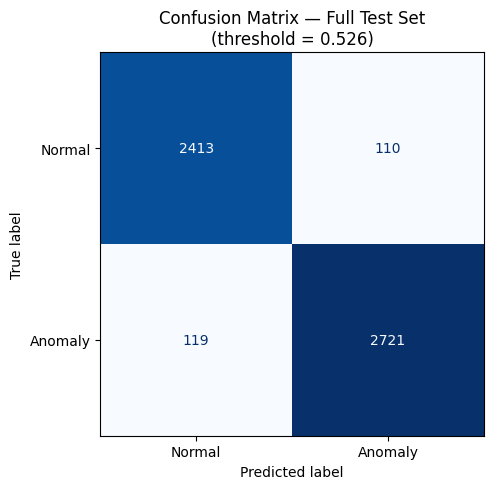

Figure saved → ../figures/lstm_classifier/confusion_matrix.png

TN=2,413  FP=110  FN=119  TP=2,721
Precision (anomaly): 0.9611
Recall    (anomaly): 0.9581
F1        (anomaly): 0.9596


In [10]:
# ── CELL 10: Confusion Matrix ─────────────────────────────────────────────────
cm = confusion_matrix(y_test_full, full_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Normal', 'Anomaly'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Full Test Set\n(threshold = {best_thresh:.3f})',
             fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved → {FIGURES_DIR / 'confusion_matrix.png'}")

tn, fp, fn, tp = cm.ravel()
print(f"\nTN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"Precision (anomaly): {tp/(tp+fp):.4f}")
print(f"Recall    (anomaly): {tp/(tp+fn):.4f}")
print(f"F1        (anomaly): {2*tp/(2*tp+fp+fn):.4f}")


---
## 11. Failure Case Analysis

Understanding *when* the model fails is as important as measuring overall accuracy. 

For visualization, we selected the top 3 sensors with the highest variance across the entire test set. These are the sensors that change the most over time, which makes it easier to see patterns in the failure cases.

Given positive = anomalous

We visualise the **sensor channels that differ most between normal and anomaly categories** for:
- **False Positives (FP):** normal windows predicted as anomalous.
- **False Negatives (FN):** anomalous windows predicted as normal.

These failure cases reveal the model's decision boundary limitations.

**Common reasons for failures:**
- FPs often arise from normal windows with unusually high sensor variance (mimicking anomaly patterns).
- FNs tend to occur for anomaly windows whose injected fault is subtle — e.g., a small velocity deviation that is within one standard deviation of the normal range.

False Positives : 110 / 2,523 normal windows  (4.4%)
False Negatives : 119 / 2,840 anomaly windows (4.2%)


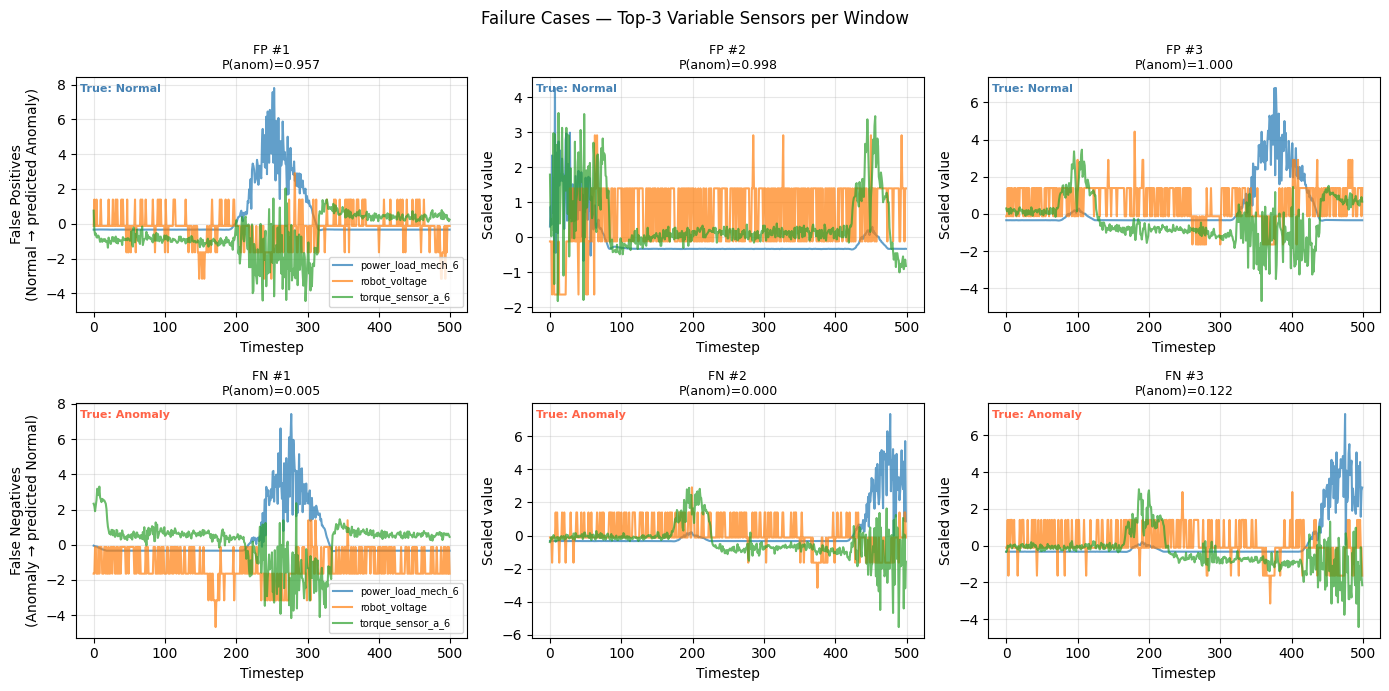

Figure saved → ../figures/lstm_classifier/failure_cases.png


In [11]:
# ── CELL 11: Failure Case Analysis ────────────────────────────────────────────
# Identify FP and FN indices from the full test set
test_pred_full_class = full_pred_class
fp_mask = (y_test_full == 0) & (test_pred_full_class == 1)
fn_mask = (y_test_full == 1) & (test_pred_full_class == 0)

print(f"False Positives : {fp_mask.sum():,} / {(y_test_full==0).sum():,} normal windows  "
      f"({100*fp_mask.sum()/(y_test_full==0).sum():.1f}%)")
print(f"False Negatives : {fn_mask.sum():,} / {(y_test_full==1).sum():,} anomaly windows "
      f"({100*fn_mask.sum()/(y_test_full==1).sum():.1f}%)")

# Select 3 representative examples of each type
rng2 = np.random.default_rng(7)
fp_idx = rng2.choice(np.where(fp_mask)[0], min(3, fp_mask.sum()), replace=False)
fn_idx = rng2.choice(np.where(fn_mask)[0], min(3, fn_mask.sum()), replace=False)

# Use first 3 most-variable sensor channels for a legible plot
sensor_names = config.get('sensors', [f'sensor_{i}' for i in range(N_FEATURES)])
variances    = X_test_full.reshape(-1, N_FEATURES).var(axis=0)
top_sensors  = np.argsort(variances)[::-1][:3]   # top-3 most variable

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
titles_fp = [f"FP #{i+1}\nP(anom)={full_pred_prob[idx]:.3f}" for i, idx in enumerate(fp_idx)]
titles_fn = [f"FN #{i+1}\nP(anom)={full_pred_prob[idx]:.3f}" for i, idx in enumerate(fn_idx)]

for col, (fp_i, fn_i) in enumerate(zip(fp_idx, fn_idx)):
    for row, (win_idx, title, true_lab) in enumerate([
        (fp_i, titles_fp[col], "Normal"),
        (fn_i, titles_fn[col], "Anomaly")
    ]):
        ax = axes[row, col]
        for s, sidx in enumerate(top_sensors):
            ax.plot(X_test_full[win_idx, :, sidx], alpha=0.7,
                    label=sensor_names[sidx] if len(sensor_names[sidx]) < 18
                          else sensor_names[sidx][:15] + "…")
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("Timestep"); ax.set_ylabel("Scaled value")
        lab_col = "steelblue" if true_lab == "Normal" else "tomato"
        ax.text(0.01, 0.97, f"True: {true_lab}", transform=ax.transAxes,
                fontsize=8, va='top', color=lab_col, fontweight='bold')
        ax.grid(alpha=0.3)
        if col == 0:
            ax.legend(fontsize=7, loc='lower right')

axes[0, 0].set_ylabel("False Positives\n(Normal → predicted Anomaly)")
axes[1, 0].set_ylabel("False Negatives\n(Anomaly → predicted Normal)")
fig.suptitle("Failure Cases — Top-3 Variable Sensors per Window", fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "failure_cases.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved → {FIGURES_DIR / 'failure_cases.png'}")


---
## 12. Using the Pre-trained Model on New Data

The model is persisted in two parts:
- **Weights** — `lstm_classifier_best.pth` (PyTorch `state_dict` containing learned parameters)
- **Config** — `lstm_classifier_config.pkl` (architecture hyperparameters for re-instantiation)

To reload the model in a fresh Python session **without retraining**, copy and paste the cell below into your notebook and follow the instructions provided.

### Required Files
Ensure these files are present in `../model/lstm_classifier/`:
- `lstm_classifier_best.pth`
- `lstm_classifier_config.pkl`


In [5]:
# ── HOW TO USE THE SAVED MODEL ON NEW DATA ──
# This cell demonstrates how to load and use the pre-trained model
# without retraining. Run this cell to see a complete example.

print("="*60)
print("LOADING PRE-TRAINED LSTM ANOMALY CLASSIFIER")
print("="*60)

# Step 1: Import required libraries
import torch
import torch.nn as nn
import pickle
import numpy as np
from pathlib import Path

# Step 2: Define the model architecture 
class TinyLSTMClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 64,
                 num_layers: int = 1, dropout: float = 0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _, (h_n, _) = self.lstm(x)
        return self.head(h_n[-1]).squeeze(1)


# Step 3: Load model function
def load_saved_model(model_dir, device=None):
    """
    Load the pre-trained model from disk.
    
    Parameters
    ----------
    model_dir : str or Path
        Directory containing lstm_classifier_config.pkl and lstm_classifier_best.pth
    device : torch.device, optional
        If None, auto-detects CUDA/MPS/CPU
    
    Returns
    -------
    model : TinyLSTMClassifier in eval mode
    """
    model_dir = Path(model_dir)
    
    # Auto-detect device
    if device is None:
        if torch.cuda.is_available():
            device = torch.device("cuda")
        elif torch.backends.mps.is_available():
            device = torch.device("mps")
        else:
            device = torch.device("cpu")
    
    # Load architecture
    with open(model_dir / "lstm_classifier_config.pkl", "rb") as f:
        arch = pickle.load(f)
    
    # Create and load model
    model = TinyLSTMClassifier(**arch).to(device)
    model.load_state_dict(torch.load(
        model_dir / "lstm_classifier_best.pth", 
        map_location=device
    ))
    model.eval()
    
    print(f"✓ Model loaded on {device}")
    print(f"  Input shape: (batch_size, 500, {arch['input_dim']})")
    print(f"  Output: anomaly probability in [0, 1]")
    
    return model, device


# Step 4: Prediction function
def predict_anomaly(model, X, device, batch_size=64):
    """
    Run inference on new data.
    
    Parameters
    ----------
    model : TinyLSTMClassifier
        Loaded model
    X : numpy.ndarray
        Input data of shape (n_samples, 500, n_features)
    device : torch.device
        Device to run inference on
    batch_size : int
        Batch size for inference
    
    Returns
    -------
    numpy.ndarray
        Anomaly probabilities of shape (n_samples,)
    """
    model.eval()
    predictions = []
    
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            batch = torch.FloatTensor(X[i:i+batch_size]).to(device)
            preds = model(batch).cpu().numpy()
            predictions.append(preds)
    
    return np.concatenate(predictions)


# Step 5: Load the saved model
print("\n" + "-"*40)
print("LOADING SAVED MODEL")
print("-"*40)

MODEL_DIR = Path("../model/lstm_classifier")
model, device = load_saved_model(MODEL_DIR)


# Step 6: Demonstration with random data (since sequences.npz is not provided)
print("\n" + "-"*40)
print("DEMONSTRATION WITH RANDOM DATA")
print("-"*40)

# Get input dimension from config
with open(MODEL_DIR / "lstm_classifier_config.pkl", "rb") as f:
    arch = pickle.load(f)
    input_dim = arch['input_dim']

# Create random data for demonstration
dummy_data = np.random.randn(10, 500, input_dim)
print(f"✓ Created random data shape: {dummy_data.shape}")

# Run predictions
predictions = predict_anomaly(model, dummy_data, device)
print(f"✓ Predictions shape: {predictions.shape}")

# Show sample predictions
print(f"\nSample predictions on random data:")
for i, prob in enumerate(predictions[:5]):
    print(f"  Window {i}: anomaly probability = {prob:.4f} ({'ANOMALY' if prob >= 0.5 else 'NORMAL'})")


# Step 7: How to use on YOUR own data
print("\n" + "="*60)
print("HOW TO USE ON YOUR OWN DATA")
print("="*60)
print("""
To use this model on your own data:

1. Prepare your data with shape: (n_windows, 500, 129)
   - 500 timesteps per window
   - 129 sensor features (same as training)

2. Load your data:
   >>> your_data = np.load("path/to/your_data.npy")

3. Get predictions:
   >>> probs = predict_anomaly(model, your_data, device)

4. Detect anomalies (using threshold 0.5):
   >>> anomalies = probs >= 0.5

5. Adjust threshold if needed (for different precision/recall trade-off):
   >>> high_precision = probs >= 0.7   # Fewer false positives
   >>> high_recall = probs >= 0.3      # Fewer false negatives
""")

print("\n✓ Model is ready for inference on new data!")
print("\n" + "="*60)
print("VERIFICATION")
print("="*60)
print("""
To verify the model loaded correctly, you can run:

>>> test_input = np.random.randn(4, 500, 129)
>>> test_output = predict_anomaly(model, test_input, device)
>>> print(f"Test output shape: {test_output.shape}")  # Should be (4,)
""")

LOADING PRE-TRAINED LSTM ANOMALY CLASSIFIER

----------------------------------------
LOADING SAVED MODEL
----------------------------------------
✓ Model loaded on mps
  Input shape: (batch_size, 500, 129)
  Output: anomaly probability in [0, 1]

----------------------------------------
DEMONSTRATION WITH RANDOM DATA
----------------------------------------
✓ Created random data shape: (10, 500, 129)
✓ Predictions shape: (10,)

Sample predictions on random data:
  Window 0: anomaly probability = 0.9860 (ANOMALY)
  Window 1: anomaly probability = 0.9810 (ANOMALY)
  Window 2: anomaly probability = 0.4137 (NORMAL)
  Window 3: anomaly probability = 0.3177 (NORMAL)
  Window 4: anomaly probability = 0.9972 (ANOMALY)

HOW TO USE ON YOUR OWN DATA

To use this model on your own data:

1. Prepare your data with shape: (n_windows, 500, 129)
   - 500 timesteps per window
   - 129 sensor features (same as training)

2. Load your data:
   >>> your_data = np.load("path/to/your_data.npy")

3. Get pre